# ASG Airlines — End-to-End Data Engineering Pipeline

This notebook orchestrates the pipeline implemented in `../src/`:

| Module | Responsibility |
|---|---|
| `src/ingestion.py` | Load raw sheets from the source workbook |
| `src/cleaning.py` | Per-table cleaning & standardization |
| `src/transformation.py` | Overnight repair, duration calc, anomaly detection, PII masking, KPIs |
| `src/validation.py` | Data-quality profiling (pre) and referential-integrity checks (post) |



**Output:** cleaned, PII-masked CSVs in `../data/processed/`, ready for the
Power BI dashboard in `../powerbi/`.


In [1]:
import sys
import logging
sys.path.insert(0, "../src")

logging.basicConfig(level=logging.INFO, format="%(message)s")

import ingestion
import cleaning
import transformation
import validation

RAW_PATH = "../data/raw/UseCase_-_Airlines.xlsx"
PROCESSED_DIR = "../data/processed"


## 1. Ingestion & Raw Data Profiling

In [2]:
data = ingestion.load_source_workbook(RAW_PATH)
raw_profile = validation.profile_raw(data)
raw_profile


Loaded sheet 'flights' with 1020 rows, 7 columns


Loaded sheet 'bookings' with 1000 rows, 9 columns


Loaded sheet 'payments' with 1000 rows, 4 columns


Loaded sheet 'passengers' with 1039 rows, 9 columns


Raw data profile:
     table  row_count  duplicate_rows  total_nulls  columns_with_nulls
   flights       1020              15           41                   1
  bookings       1000               0           45                   1
  payments       1000               0           48                   1
passengers       1039               0           10                   1


,table,row_count,duplicate_rows,total_nulls,columns_with_nulls
0,flights,1020,15,41,1
1,bookings,1000,0,45,1
2,payments,1000,0,48,1
3,passengers,1039,0,10,1


## 2. Cleaning

Each table is cleaned independently. Flights must be cleaned first since
bookings are validated against the resulting set of valid flight_ids.


In [3]:
flights = cleaning.clean_flights(data["flights"])
passengers = cleaning.clean_passengers(data["passengers"])
bookings = cleaning.clean_bookings(data["bookings"], valid_flight_ids=set(flights["flight_id"]))
payments = cleaning.clean_payments(data["payments"])

print("Clean shapes -> flights:", flights.shape, "passengers:", passengers.shape,
      "bookings:", bookings.shape, "payments:", payments.shape)


Flight IDs not matching expected carrier-code pattern: 0


Exact duplicate flight rows dropped: 15


Residual duplicate flight_id rows dropped (kept first): 1


Impossible routes (source == destination) dropped: 0


Rows dropped for unparseable timestamps: 0


...

Passenger ages outside 0-110 set to null: 0


Bookings dropped for missing key fields: 0


Orphan bookings (flight_id not in cleaned flights): 0


Payments dropped for missing/invalid amount: 78


Clean shapes -> flights: (1004, 6) passengers: (1000, 9) bookings: (1000, 9) payments: (922, 4)


## 3. Transformation

### 3.1 Overnight repair & duration
Timestamps are full datetimes. If `arrival_time <= departure_time`, the
record's date didn't roll over correctly for a flight crossing midnight —
the arrival date is advanced by a day, then `duration_minutes` is recomputed
from the corrected timestamps (any pre-existing `duration` column from the
source is ignored). `is_overnight` separately flags any flight whose
departure/arrival calendar dates differ — a real operational attribute, not
an error.

### 3.2 Route-level anomaly detection
No scheduled-time field exists, so "delay" is operationalized as a
route-relative statistical outlier: a flight whose duration is more than 2
standard deviations from its own route's mean (routes need ≥3 flights to be
judged).


In [4]:
flights = transformation.repair_overnight_and_compute_duration(flights)
flights = transformation.flag_route_duration_anomalies(flights)
flights.head()


Broken overnight records repaired (arrival <= departure): 1


Unrecoverable non-positive-duration rows dropped: 0


Genuine overnight (cross-midnight) flights: 122


Route-level duration anomalies flagged: 1


,flight_id,airline,source,destination,departure_time,arrival_time,duration_minutes,is_overnight,anomaly_duration_outlier
0,SJ010,SpiceJet,CCU,MAA,2026-04-20 23:38:41.701,2026-04-21 02:32:41.701,174.0,True,False
1,AI155,Air India,BOM,CCU,2026-04-20 23:35:41.703,2026-04-21 01:23:41.703,108.0,True,False
2,UK094,Vistara,BOM,CCU,2026-04-20 23:26:41.702,2026-04-21 01:11:41.702,105.0,True,False
3,AI245,Air India,BOM,CCU,2026-04-20 23:07:41.704,2026-04-21 01:43:41.704,156.0,True,False
4,AI192,Air India,MAA,BOM,2026-04-20 23:05:41.703,2026-04-21 04:04:41.703,299.0,True,False


### 3.3 PII Masking

| Field | Technique | Rationale |
|---|---|---|
| email | Partial mask (`j***@domain`) | Readable enough for support use, full address hidden |
| phone / emergency_contact_phone | Partial mask (last 4 digits visible) | Common support-tooling pattern |
| aadhaar_id | SHA-256 hash (16 hex chars) | Government ID, no reporting use — irreversible |
| passport_number | SHA-256 hash (16 hex chars) | Same rationale as Aadhaar |

Raw PII columns are dropped immediately after masking — they never reach `data/processed/`.


In [5]:
passengers = transformation.mask_passenger_pii(passengers)
bookings = transformation.mask_booking_pii(bookings)
passengers[["passenger_id", "email_masked", "phone_masked", "aadhaar_hash"]].head()


,passenger_id,email_masked,phone_masked,aadhaar_hash
0,P1000,v****************@gmail.com,+91-******3790,99466baa9b8fe69a
1,P1001,k************@hotmail.com,+91-******2297,6d05ccbeb5011dd5
2,P1002,m*********@outlook.com,+91-******5092,3e24ac79e2c95679
3,P1003,m**********@hotmail.com,+91-******7151,4e880723014ee24b
4,P1004,s**************@outlook.com,+91-******5113,3ca09c31f18da71a


## 4. Post-Cleaning Validation\n\nConfirms referential integrity and that no raw PII survived before anything is exported.

In [6]:
validation.validate_cleaned_flights(flights)
validation.validate_cleaned_bookings(bookings, set(flights["flight_id"]), set(passengers["passenger_id"]))
validation.validate_cleaned_passengers(passengers)
validation.validate_cleaned_payments(payments, set(bookings["booking_id"]))
print("Validation complete — see log output above for any warnings.")


[flights] passed all validation checks.


[bookings] passed all validation checks.


[passengers] passed all validation checks.


[payments] passed all validation checks.


Validation complete — see log output above for any warnings.


## 5. Business KPIs

In [7]:
kpis = transformation.compute_kpis(flights, bookings)
kpis["avg_duration"]


,metric,value
0,avg_flight_duration_minutes,164.75


In [8]:
kpis["route_traffic"].head(10)

,source,destination,flight_count
0,BOM,CCU,90
1,CCU,DEL,72
2,MAA,BLR,65
3,BLR,BOM,60
4,HYD,MAA,57
5,DEL,HYD,54
6,HYD,DEL,42
7,BOM,DEL,39
8,CCU,BOM,33
9,DEL,BLR,29


In [9]:
kpis["airline_distribution"]

,airline,flight_count
0,IndiGo,249
1,SpiceJet,236
2,Air India,233
3,Vistara,218
4,Unknown,68


In [10]:
kpis["anomaly_summary"]

,metric,count
0,overnight_flights,122
1,route_level_duration_outliers,1


In [11]:
kpis["booking_status_distribution"]

,status,count
1,CONFIRMED,320
0,CANCELLED,314
2,PENDING,291
3,UNKNOWN,75


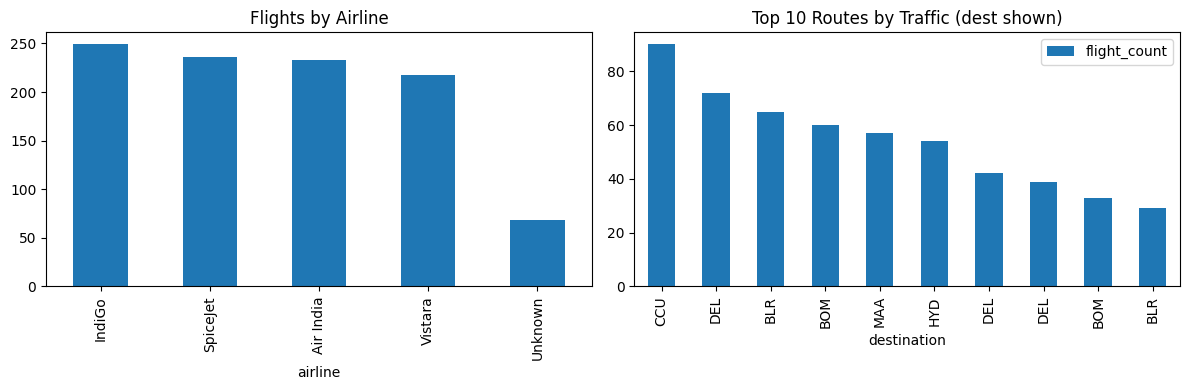

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
kpis["airline_distribution"].set_index("airline")["flight_count"].plot(kind="bar", ax=axes[0], title="Flights by Airline")
kpis["route_traffic"].head(10).plot(x="destination", y="flight_count", kind="bar", ax=axes[1], title="Top 10 Routes by Traffic (dest shown)")
plt.tight_layout()
plt.show()


## 6. Export to `data/processed/`

These four files are the pipeline's deliverable. Power BI reads them
directly — `bookings` carries the foreign keys (`flight_id`, `passenger_id`)
needed to relate all four tables, so no separate star-schema files are
required.


In [13]:
import os
os.makedirs(PROCESSED_DIR, exist_ok=True)

flights.to_csv(f"{PROCESSED_DIR}/cleaned_flights.csv", index=False)
bookings.to_csv(f"{PROCESSED_DIR}/cleaned_bookings.csv", index=False)
payments.to_csv(f"{PROCESSED_DIR}/cleaned_payments.csv", index=False)
passengers.to_csv(f"{PROCESSED_DIR}/cleaned_passengers.csv", index=False)

print("Exported to", PROCESSED_DIR)
os.listdir(PROCESSED_DIR)


Exported to ../data/processed


['cleaned_payments.csv',
 'cleaned_bookings.csv',
 'cleaned_passengers.csv',
 'cleaned_flights.csv']

## Summary

| Table | Rows in | Rows out | Notes |
|---|---|---|---|
| flights | 1,020 | 1,004 | dedup + impossible-route drops |
| passengers | 1,039 | 1,000 | dedup only |
| bookings | 1,000 | 1,000 | orphan FK + missing-key drops |
| payments | 1,000 | 922 | invalid/non-numeric amount drops |


